In [7]:
import torch
import os
import numpy as np
import torch
import random
import math
from dipy.io.image import load_nifti
from dipy.io import read_bvals_bvecs
from dipy.core.gradients import gradient_table
import data.utils_dataloader as utils
from itertools import islice
import h5py
import os
import torchio as tio
from itertools import permutations 
import skimage.metrics as metrics
import data
from option import args
import numpy as np
import utility
import utils
import matplotlib.pyplot as plt

from dipy.io.gradients import read_bvals_bvecs
from dipy.core.gradients import gradient_table
np.seterr(all="ignore")

loaded = {}
loaded_gt ={}
path,tot = "",""

def load_path(base_dir,ids):
    base_dir_7t = [base_dir + "/HCP_7T/" + i   for i in ids]
    base_dir_3t = [base_dir + "/HCP_3T/" + i   for i in ids]
    path_7t = {}
    path_3t = {}
    for i in base_dir_7t:
        path_7t[i[-6:]] = {"h5" : i + "/" + i[-6:] + ".h5"
                        , "GT" : i + "/" + i[-6:] + "_GT.h5",
                        "bvals" : i + "/T1w/Diffusion_7T/bvals" , "bvecs" : i + "/T1w/Diffusion_7T/bvecs"}
    for i in base_dir_3t:
        path_3t[i[-6:]] = {"h5" : i + "/" + i[-6:] + ".h5"
                        , "GT" : i + "/" + i[-6:] + "_GT.h5",
                        "bvals" : i + "/T1w/Diffusion/bvals" , "bvecs" : i + "/T1w/Diffusion/bvecs"}
    path = {'3T': path_3t, "7T":  path_7t}
    p = list(path_7t.keys())
    q = list(path_3t.keys())
    common = list(set(p) & set(q))

    return path,len(common)

def load_data(base_dir,ids):
    ids.sort()
    path,tot = load_path(base_dir,ids)
    act_ids = []
    for i in ids:
        name = path['3T'][i]['h5']
        if(not os.path.isfile(name)):
            continue
        
        res_vol = h5py.File(name, 'r')
        
        name = path['3T'][i]['GT']
        res = h5py.File(name, 'r')
        
        loaded[i] = {'vol0':res_vol.get('volumes0')[:]
                            ,'mask':res_vol.get('mask')[:],
                    'ADC':res.get('ADC')[:],
                    'FA':res.get('FA')[:] ,
                    'color_FA':res.get('color_FA')[:]}
        
        res_vol.close()
        res.close()

        name = path['7T'][i]['h5']
        if(not os.path.isfile(name)):
            continue
        
        res_vol = h5py.File(name, 'r')
        
        name = path['7T'][i]['GT']
        res = h5py.File(name, 'r')
        
        
        loaded_gt[i] = {'vol0':res_vol.get('volumes0')[:]
                            ,'mask':res_vol.get('mask')[:],
                    'ADC':res.get('ADC')[:],
                    'FA':res.get('FA')[:] ,
                    'color_FA':res.get('color_FA')[:],
                    'tensor_vals':res.get('tensor_vals')[:]}
                
        res_vol.close()
        res.close()

        act_ids.append(i)
    return act_ids




def interpolate(data,size):
    
    if(len(data.shape)==3):
        inp = torch.unsqueeze(data, 0)
    else:
        inp = torch.permute(data, (3,0,1,2))
    inp = torch.unsqueeze(inp, 0)
    interpolated = torch.nn.functional.interpolate(inp,size = torch.Size(size))
    interpolated = torch.permute(interpolated, (2,3,4,1,0))
    
    if(len(data.shape)==3):
        interpolated = torch.squeeze(interpolated)
    return torch.squeeze(interpolated)

number of common Subjects  171


In [8]:
from option import args

ids = utils.get_ids()
# ids.sort()
total_vols = args.no_vols+args.test_vols
ids.sort()
ids = ids[:total_vols]
ids = np.random.choice(ids,total_vols,replace = False)
args.thres = 0.5
print(ids)


['100610' '104416' '115825' '108323' '111312' '131722' '111514' '114823'
 '118225' '126426' '116726' '130518' '102816' '128935' '109123' '105923'
 '115017' '125525' '130114' '102311']


In [9]:
args.dir

'/storage'

In [10]:
ids = ids[:10]

In [11]:
load_data(args.dir,ids)

['100610',
 '104416',
 '108323',
 '111312',
 '111514',
 '114823',
 '115825',
 '118225',
 '126426',
 '131722']

In [12]:
idx = "100610"

In [13]:

vol_lr = torch.from_numpy(loaded[idx]['vol0'])

vol_hr = torch.from_numpy(loaded_gt[idx]['vol0'])

size = vol_lr.shape[:3]
vol_hr = interpolate(vol_hr,size)

adc = interpolate(torch.from_numpy(loaded_gt[idx]['ADC']),size)
fa = interpolate(torch.from_numpy(loaded_gt[idx]['FA']),size)
rgb = interpolate(torch.from_numpy(loaded_gt[idx]['color_FA']),size)

In [312]:
def permute_dir(data,x):
    if(len(data.shape) == 3):
        
        if x == 2:
            data = torch.permute(data,(1,2,0))
        if x == 1:
            data =torch.permute(data,(0,2,1))
    else:
        if x == 2:
            data = torch.permute(data,(1,2,0,3))
        if x == 1:
            data =torch.permute(data,(0,2,1,3))
    return data

def blk_points_pair(datalr,datahr,adc,fa,rgb,blk_size = (32,32,5)):
    
    shpind = torch.nonzero(datalr)
    xmin,xmax = torch.min(shpind[:,0]).item(),torch.max(shpind[:,0]).item()
    ymin,ymax = torch.min(shpind[:,1]).item(),torch.max(shpind[:,1]).item()
    zmin,zmax = torch.min(shpind[:,1]).item(),torch.max(shpind[:,2]).item()

    lr_start = [xmin,ymin,zmin]

    ranges = {}
    ranges_key = blk_size,(blk_size[0],blk_size[2],blk_size[1]),(blk_size[2],blk_size[1],blk_size[0])

    lr_end = [xmax - ranges_key[0][0] + 1,ymax - ranges_key[0][1] + 1,zmax - ranges_key[0][2] + 1]
    ranges[ranges_key[0]] = [np.arange(lr_start[i], lr_end[i], ranges_key[0][i]) for i in range(3)]


    lr_end = [xmax - ranges_key[1][0] + 1,ymax - ranges_key[1][1] + 1,zmax - ranges_key[1][2] + 1]
    ranges[ranges_key[1]] = [np.arange(lr_start[i], lr_end[i], ranges_key[1][i]) for i in range(3)]

    lr_end = [xmax - ranges_key[2][0] + 1,ymax - ranges_key[2][1] + 1,zmax - ranges_key[2][2] + 1]
    ranges[ranges_key[2]] = [np.arange(lr_start[i], lr_end[i], ranges_key[2][i]) for i in range(3)]
    
    sample_req = 50
    samples = np.random.randint(3, size=sample_req)
    blks = {"lr":[],"adc":[],"fa":[],"rgb":[],"hr":[]}
    for curr_dir in samples:    
        temp = [len(i) for i in ranges[ranges_key[curr_dir]]]
        ii,jj,kk = [np.random.randint(i,size=1)[0] for i in temp]
        curr_blk = ranges_key[curr_dir]
        curr_ranges = ranges[ranges_key[curr_dir]]
        x,y,z = curr_ranges[0][ii],curr_ranges[1][jj],curr_ranges[2][kk]
        temp_lr = np.array([x, x + curr_blk[0]-1, 
                            y, y + curr_blk[1]-1, 
                            z, z + curr_blk[2]-1]).astype(int)
        if x == 2:
            torch.permute(res['lr'][1],(1,2,0,3))
        if x == 1:
            torch.permute(res['lr'][1],(0,2,1,3))
        
        blks["lr"].append(permute_dir(datalr[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...],curr_dir))
        blks["hr"].append(permute_dir(datahr[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...],curr_dir))
        blks["adc"].append(permute_dir(adc[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...],curr_dir))
        blks["fa"].append(permute_dir(fa[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...],curr_dir))
        blks["rgb"].append(permute_dir(rgb[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...],curr_dir))

    return blks,len(blks["lr"])

In [313]:
len(res['adc'][0].shape)

3

In [314]:
curr_permute = lambda x : torch.permute(x,)

In [315]:
idx = '114823'
vol_lr = torch.from_numpy(loaded[idx]['vol0'])

vol_hr = torch.from_numpy(loaded_gt[idx]['vol0'])

size = vol_hr.shape[:3]
vol_lr = interpolate(vol_lr,size)

adc = interpolate(torch.from_numpy(loaded_gt[idx]['ADC']),size)
fa = interpolate(torch.from_numpy(loaded_gt[idx]['FA']),size)
rgb = interpolate(torch.from_numpy(loaded_gt[idx]['color_FA']),size)

In [316]:
adc.shape

torch.Size([127, 171, 125])

In [317]:
datalr = vol_lr
blk_size = (32,32,5)

In [318]:
ranges_key[0]

(32, 32, 5)

In [319]:
ranges[ranges_key[0]]

[array([ 0, 32, 64]),
 array([  0,  32,  64,  96, 128]),
 array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
         65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115])]

In [324]:
res,samples = blk_points_pair(vol_lr,vol_hr,adc,fa,rgb)

In [337]:
idx = 25

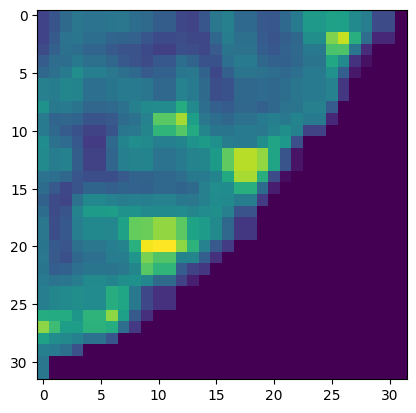

In [340]:
plt.imshow(res['lr'][idx][:,:,2,0])

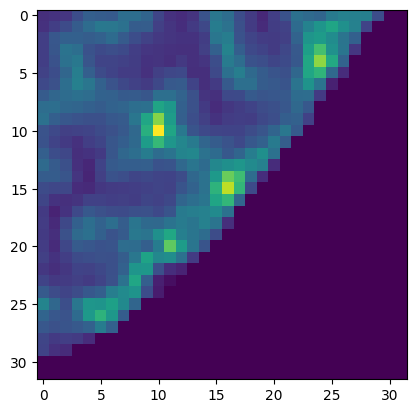

In [341]:
plt.imshow(res['hr'][idx][:,:,2,0])

In [189]:
blks = {"lr":[],"adc":[],"fa":[],"rgb":[],"hr":[]}
for x in samples:    
    ii,jj,kk = [np.random.randint(i,size=1)[0] for i in [len(i) for i in ranges[ranges_key[x]]]]
    curr_blk = ranges_key[x]
    curr_ranges = ranges[ranges_key[x]]
    x,y,z = curr_ranges[0][ii],curr_ranges[1][jj],curr_ranges[2][kk]
    temp_lr = np.array([x, x + curr_blk[0]-1, 
                        y, y + curr_blk[1]-1, 
                        z, z + curr_blk[2]-1]).astype(int)
    blks["lr"].append(datalr[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...])
    blks["hr"].append(datahr[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...])
    blks["adc"].append(adc[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...])
    blks["fa"].append(fa[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...])
    blks["rgb"].append(rgb[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...])
    

SyntaxError: expression expected after dictionary key and ':' (3318349340.py, line 1)

In [166]:
shpind = torch.nonzero(datalr)
xmin,xmax = torch.min(shpind[:,0]).item(),torch.max(shpind[:,0]).item()
ymin,ymax = torch.min(shpind[:,1]).item(),torch.max(shpind[:,1]).item()
zmin,zmax = torch.min(shpind[:,1]).item(),torch.max(shpind[:,2]).item()



lr_start = [xmin,ymin,zmin]

ranges = {}
ranges_key = blk_size,(blk_size[0],blk_size[2],blk_size[1]),(blk_size[2],blk_size[1],blk_size[0])

lr_end = [xmax - blk_size[0] + 1,ymax - blk_size[1] + 1,zmax - blk_size[2] + 1]

ranges[ranges_key[0]] = [np.arange(lr_start[i], lr_end[i], ranges_key[0][i]) for i in range(3)]

blk_size = blk_size[0],blk_size[2],blk_size[1]

lr_end = [xmax - blk_size[0] + 1,ymax - blk_size[1] + 1,zmax - blk_size[2] + 1]

ranges[ranges_key[1]] = [np.arange(lr_start[i], lr_end[i], ranges_key[1][i]) for i in range(3)]

lr_end = [xmax - blk_size[0] + 1,ymax - blk_size[1] + 1,zmax - blk_size[2] + 1]

ranges[ranges_key[2]] = [np.arange(lr_start[i], lr_end[i], ranges_key[2][i]) for i in range(3)]





In [138]:
datalr.shape

torch.Size([127, 171, 125, 7])

In [ ]:
x

In [139]:
temp = [len(i) for i in ranges]

In [142]:
temp

[3, 5, 31]

In [143]:
x = 1
for i in temp:
    x*=i

3
5
31


In [141]:
x

465

In [132]:
len(ranges)

3

In [114]:
lr_start

[0, 0, 0]

In [69]:
idx = '114823'
vol_lr = torch.from_numpy(loaded[idx]['vol0'])

vol_hr = torch.from_numpy(loaded_gt[idx]['vol0'])

size = vol_hr.shape[:3]
vol_lr = interpolate(vol_lr,size)


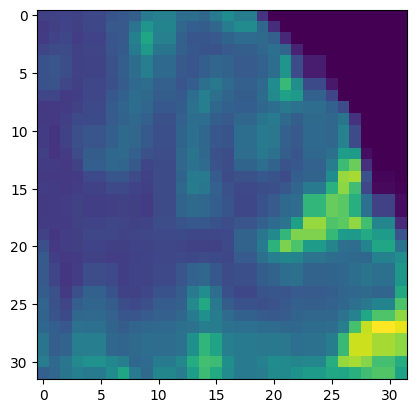

In [113]:
%matplotlib inline
plt.imshow(vol_lr[32:64,150,64:96,0])

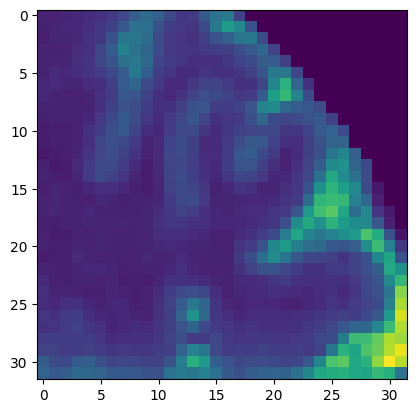

In [112]:
%matplotlib inline
plt.imshow(vol_hr[32:64,150,64:96,0])

In [84]:
vol_lr.shape

torch.Size([127, 171, 125, 7])

In [73]:
106-60

46

In [85]:
blk_size = 32

In [104]:
shpind = torch.nonzero(vol_lr)
xmin,xmax = torch.min(shpind[:,0]).item(),torch.max(shpind[:,0]).item()
ymin,ymax = torch.min(shpind[:,1]).item(),torch.max(shpind[:,1]).item()
zmin,zmax = torch.min(shpind[:,1]).item(),torch.max(shpind[:,2]).item()


lr_start = [xmin,ymin,zmin]

lr_end = [xmax - blk_size + 1,ymax - blk_size + 1 ,zmax - blk_size + 1 ]

ranges = [np.arange(lr_start[i], lr_end[i], blk_size) for i in range(3)]


ind_block_lr = []
ind_block_hr = []
count = 0

for ii in np.arange(0, ranges_lr[0].shape[0]):
    for jj in np.arange(0, ranges_lr[1].shape[0]):
        for kk in np.arange(0, ranges_lr[2].shape[0]):
            
            x,y,z = ranges_lr[0][ii],ranges_lr[1][jj],ranges_lr[2][kk]
            temp_lr = np.array([x, x + blk_size[0]-1, 
                                y, y + blk_size[1]-1, 
                                z, z + blk_size[2]-1]).astype(int)

            x,y,z = ranges_hr[0][ii],ranges_hr[1][jj],ranges_hr[2][kk]
            temp_hr = np.array([x, x + blk_size_hr[0]-1,
                                y, y + blk_size_hr[1]-1,
                                z, z + blk_size_hr[2]-1]).astype(int)


            curr_blk = datalr[temp_lr[0]:temp_lr[1]+1, temp_lr[2]:temp_lr[3]+1, temp_lr[4]:temp_lr[5]+1, ...]

            curr_blk_hr = datahr[temp_hr[0]:temp_hr[1]+1, temp_hr[2]:temp_hr[3]+1, temp_hr[4]:temp_hr[5]+1, ...]
            # psnr_sim = float(metrics.peak_signal_noise_ratio(curr_blk.numpy(),curr_blk_lr.numpy(),data_range=1))


            if(self.enable_thres):
                if((torch.numel(curr_blk_hr) != 0 and torch.count_nonzero(curr_blk_hr)/torch.numel(curr_blk_hr) > self.thres)):
                    ind_block_lr.append(temp_lr)
                    ind_block_hr.append(temp_hr)
                    count = count + 1
            else:
                ind_block_lr.append(temp_lr)
                ind_block_hr.append(temp_hr)
                count = count + 1

ind_block_lr = np.stack(ind_block_lr)
ind_block_lr = ind_block_lr.astype(int)
ind_block_hr = np.stack(ind_block_hr)
ind_block_hr = ind_block_hr.astype(int)



In [105]:
lr_end

[95, 139, 93]

In [106]:
lr_start

[0, 0, 0]

In [107]:
ranges

[array([ 0, 32, 64]), array([  0,  32,  64,  96, 128]), array([ 0, 32, 64])]

In [342]:
import data

In [346]:
temp = data.HCP_dataset_h5_arb

In [347]:
temp.load_data(args.dir,ids)

['100610',
 '104416',
 '108323',
 '111312',
 '111514',
 '114823',
 '115825',
 '118225',
 '126426',
 '131722']

In [351]:
next(temp)

TypeError: 'module' object is not an iterator

In [ ]:
temp.hcp_data()